# Análise dos resultados do experimento

Este notebook consolida os resultados dos 7 tratamentos avaliados no experimento:

1. SonarQube
2. ChatGPT zero-shot
3. Claude zero-shot
4. DeepSeek zero-shot
5. ChatGPT few-shot
6. Claude few-shot
7. DeepSeek few-shot

A referência de acerto é o arquivo `Analise-base-MLCQ/MLCQ_ground_truth_completo.xlsx`.

**Critério adotado para empate no MLCQ:** quando `votos_tem_smell == votos_nao_tem_smell`, o veredito de referência será considerado como presença do smell, pois pelo menos um avaliador humano indicou a presença.

In [1]:
# Caso ainda não tenha instalado no ambiente:
# %pip install pandas numpy matplotlib scikit-learn statsmodels openpyxl

from pathlib import Path
import json
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

## 1. Configuração dos caminhos

O notebook foi pensado para ficar dentro da pasta `Analise-resultados-experimento`. Por isso, por padrão ele sobe um nível com `..` para chegar na raiz do projeto.

Se você executar o notebook a partir de outro local, ajuste `PROJECT_ROOT` manualmente.

In [2]:
# Se o notebook estiver em: raiz/Analise-resultados-experimento/analise_resultados_experimento.ipynb
PROJECT_ROOT = Path("..").resolve()

PATH_GROUND_TRUTH = PROJECT_ROOT / "Analise-base-MLCQ" / "MLCQ_ground_truth_completo.xlsx"
PATH_PROMPTS = PROJECT_ROOT / "Script-Api-LLMs" / "prompts.json"
PATH_SONAR = PROJECT_ROOT / "sonar-trechos" / "sonar_snippet_issues.jsonl"
PATH_LLM_OUTPUTS = {
    "chatgpt": PROJECT_ROOT / "Script-Api-LLMs" / "outputs_openai.jsonl",
    "claude": PROJECT_ROOT / "Script-Api-LLMs" / "outputs_claude.jsonl",
    "deepseek": PROJECT_ROOT / "Script-Api-LLMs" / "outputs_deepseek.jsonl",
}

OUTPUT_DIR = PROJECT_ROOT / "Analise-resultados-experimento" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for nome, caminho in {
    "ground_truth": PATH_GROUND_TRUTH,
    "prompts": PATH_PROMPTS,
    "sonar": PATH_SONAR,
    **PATH_LLM_OUTPUTS,
}.items():
    print(f"{nome:15s} -> {caminho} | existe? {caminho.exists()}")

ground_truth    -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Analise-base-MLCQ/MLCQ_ground_truth_completo.xlsx | existe? True
prompts         -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/prompts.json | existe? True
sonar           -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/sonar-trechos/sonar_snippet_issues.jsonl | existe? True
chatgpt         -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/outputs_openai.jsonl | existe? True
claude          -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/outputs_claude.jsonl | existe? True
deepseek        -> /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/outputs_deepseek.jsonl | existe? True


## 2. Funções auxiliares

Estas funções normalizam nomes de smells, carregam arquivos JSONL e transformam respostas textuais das LLMs em predições binárias.

In [3]:
def read_jsonl(path: Path) -> pd.DataFrame:
    """Lê um arquivo .jsonl e retorna um DataFrame."""
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def remove_accents(text):
    """Remove acentos de um texto."""
    if pd.isna(text):
        return text

    text = str(text)
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(ch)
    )


def normalize_smell(smell):
    """Padroniza os nomes dos smells para bater MLCQ, prompts, Sonar e LLMs."""
    if pd.isna(smell):
        return smell

    s = remove_accents(str(smell)).lower().strip()
    s = s.replace("_", "-").replace("/", " ")
    s = re.sub(r"\s+", " ", s)

    aliases = {
        "blob": "blob",
        "god class": "blob",
        "blob god class": "blob",
        "blob-god-class": "blob",

        "data class": "data class",
        "dataclass": "data class",
        "data-class": "data class",

        "feature envy": "feature envy",
        "feature-envy": "feature envy",

        "long method": "long method",
        "long-method": "long method",
    }

    return aliases.get(s, s)


def yes_no_to_int(value):
    """Converte respostas SIM/NÃO e variações para 1/0 quando possível."""
    if pd.isna(value):
        return np.nan

    s = remove_accents(str(value)).lower().strip()

    if s in {
        "sim", "s", "yes", "y", "true", "1",
        "tem_smell", "tem smell", "presente"
    }:
        return 1

    if s in {
        "nao", "não", "n", "no", "false", "0",
        "nao_tem_smell", "nao tem smell", "ausente"
    }:
        return 0

    return np.nan


def sim_nao_to_int(value):
    """
    Conversão auxiliar usada especificamente na extração das respostas das LLMs.
    Mantém retorno como np.nan para ficar compatível com o restante do notebook.
    """
    return yes_no_to_int(value)


def normalize_text_for_extraction(text):
    """
    Normaliza o texto da resposta da LLM antes da extração.
    Remove markdown comum, acentos e padroniza espaços.
    """
    if text is None or pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("**", "")
    text = text.replace("__", "")
    text = text.replace("*", "")
    text = text.replace("`", "")
    text = text.replace("\r", "\n")
    text = remove_accents(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_sample_id_from_component(component):
    """Extrai o sample_id do componente do Sonar. Ex.: Snippet_3700666.java -> 3700666."""
    if pd.isna(component):
        return np.nan

    match = re.search(r"Snippet_(\d+)\.java", str(component))
    return int(match.group(1)) if match else np.nan


def sonar_rule_to_smell(rule):
    """Converte a regra custom-java-smells:* para o smell correspondente."""
    if pd.isna(rule):
        return np.nan

    r = str(rule).lower()

    mapping = {
        "blob-god-class": "blob",
        "god-class": "blob",
        "data-class": "data class",
        "feature-envy": "feature envy",
        "long-method": "long method",
    }

    for key, smell in mapping.items():
        if key in r:
            return smell

    return normalize_smell(r.split(":")[-1])


def extract_label_from_response(response, smell):
    """
    Extrai o veredito da LLM para um smell específico.

    Retorna:
    1 para SIM
    0 para NÃO
    np.nan quando não conseguir extrair com segurança.

    A função cobre respostas como:
    - Blob: SIM
    - Data Class: **NÃO**
    - SIM (Long Method) / NÃO (Feature Envy)
    - NÃO \\n NÃO, usando a ordem esperada dos prompts.
    """
    if response is None or pd.isna(response):
        return np.nan

    text = normalize_text_for_extraction(response)

    if not text:
        return np.nan

    text_lower = text.lower()
    smell_norm = normalize_smell(smell)

    aliases = {
        "blob": [
            r"blob",
            r"god\s*class",
            r"blob\s*/\s*god\s*class",
            r"blob\s+god\s*class",
        ],
        "data class": [
            r"data\s*class",
            r"dataclass",
        ],
        "feature envy": [
            r"feature\s*envy",
            r"feature[-_\s]*envy",
        ],
        "long method": [
            r"long\s*method",
            r"longmethod",
        ],
    }

    yes_no = r"(sim|nao|não|yes|no|true|false|1|0)"

    smell_aliases = aliases.get(smell_norm, [re.escape(str(smell_norm))])

    # Caso 1:
    # Formato padrão.
    # Exemplo: Long Method: SIM
    # Exemplo: Data Class: **NÃO**
    for alias in smell_aliases:
        pattern = rf"{alias}\s*[:=\-–—]?\s*{yes_no}\b"
        match = re.search(pattern, text_lower, flags=re.IGNORECASE)
        if match:
            return sim_nao_to_int(match.group(1))

    # Caso 2:
    # Veredito antes do nome do smell.
    # Exemplo: SIM (Long Method) / NÃO (Feature Envy)
    for alias in smell_aliases:
        pattern = rf"\b{yes_no}\s*\(?\s*{alias}\s*\)?"
        match = re.search(pattern, text_lower, flags=re.IGNORECASE)
        if match:
            return sim_nao_to_int(match.group(1))

    # Caso 3:
    # Texto explicativo próximo ao nome do smell.
    # Exemplo: Long Method -> SIM, pois...
    for alias in smell_aliases:
        pattern = rf"{alias}.{{0,80}}?\b{yes_no}\b"
        match = re.search(pattern, text_lower, flags=re.IGNORECASE | re.DOTALL)
        if match:
            return sim_nao_to_int(match.group(1))

    # Caso 4:
    # Frases como "não é Blob", "não possui Feature Envy", "é Long Method".
    for alias in smell_aliases:
        neg_pattern = rf"\b(nao|não|no|false)\s+(e|eh|é|possui|tem|apresenta|caracteriza).*?{alias}"
        pos_pattern = rf"\b(e|eh|é|possui|tem|apresenta|caracteriza).*?{alias}"

        if re.search(neg_pattern, text_lower, flags=re.IGNORECASE):
            return 0

        if re.search(pos_pattern, text_lower, flags=re.IGNORECASE):
            return 1

    # Caso 5:
    # Resposta em linhas ou tokens sem nome explícito do smell.
    # Usa a ordem esperada dos prompts:
    # classe: Blob, Data Class
    # método: Long Method, Feature Envy
    tokens = re.findall(yes_no, text_lower, flags=re.IGNORECASE)
    tokens = [remove_accents(t).lower().strip() for t in tokens]

    if len(tokens) >= 2:
        if smell_norm == "blob":
            return sim_nao_to_int(tokens[0])

        if smell_norm == "data class":
            return sim_nao_to_int(tokens[1])

        if smell_norm == "long method":
            return sim_nao_to_int(tokens[0])

        if smell_norm == "feature envy":
            return sim_nao_to_int(tokens[1])

    # Se houver apenas um SIM/NÃO sem o nome do smell, é ambíguo,
    # porque os prompts normalmente perguntam sobre dois smells.
    # Então é melhor manter como não extraído.
    return np.nan


def safe_rate(num, den):
    return np.nan if den == 0 else num / den

## 3. Carregar e preparar o ground truth do MLCQ

Aqui é aplicada a regra central do experimento:

- `1` quando há presença do smell.
- `0` quando não há presença do smell.
- Em casos de empate, considerar `1`.

In [4]:
gt = pd.read_excel(PATH_GROUND_TRUTH)

gt["smell"] = gt["smell"].apply(normalize_smell)
gt["sample_id"] = gt["sample_id"].astype(int)

# Regra de referência:
# - se votos_tem_smell == votos_nao_tem_smell, considera presença do smell.
# - se não houver colunas de votos, usa veredito_final como fallback.
if {"votos_tem_smell", "votos_nao_tem_smell"}.issubset(gt.columns):
    gt["y_true"] = np.where(
        gt["votos_tem_smell"] >= gt["votos_nao_tem_smell"],
        1,
        0,
    )
else:
    gt["y_true"] = gt["veredito_final"].map({"tem_smell": 1, "nao_tem_smell": 0})

gt["ground_truth_empate"] = (
    gt.get("votos_tem_smell", pd.Series(index=gt.index, dtype=float))
    == gt.get("votos_nao_tem_smell", pd.Series(index=gt.index, dtype=float))
)

gt_base = gt[[
    "sample_id", "type", "smell", "code_name", "repository", "path",
    "start_line", "end_line", "link", "total_avaliacoes",
    "votos_tem_smell", "votos_nao_tem_smell", "veredito_final",
    "ground_truth_empate", "y_true"
]].copy()

print(gt_base.shape)
display(gt_base.head())
display(gt_base.groupby(["type", "smell", "y_true"]).size().reset_index(name="n"))
print("Empates considerados como presença:", int(gt_base["ground_truth_empate"].sum()))

(8711, 15)


,sample_id,type,smell,code_name,repository,path,start_line,end_line,link,total_avaliacoes,votos_tem_smell,votos_nao_tem_smell,veredito_final,ground_truth_empate,y_true
0,3698323,class,blob,com.amazon.ask.dispatcher.request.handler.impl.PlaybackNearlyFinishedRequestHandler,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java,26,59,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-core/src/com/amazon/ask/dispatcher/request/hand...,1,0,1,nao_tem_smell,False,0
1,3698323,class,data class,com.amazon.ask.dispatcher.request.handler.impl.PlaybackNearlyFinishedRequestHandler,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java,26,59,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-core/src/com/amazon/ask/dispatcher/request/hand...,1,0,1,nao_tem_smell,False,0
2,3698602,function,feature envy,com.amazon.ask.request.mapper.impl.BaseRequestMapper.Builder#build,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java,79,81,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/...,1,0,1,nao_tem_smell,False,0
3,3698602,function,long method,com.amazon.ask.request.mapper.impl.BaseRequestMapper.Builder#build,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java,79,81,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/...,1,0,1,nao_tem_smell,False,0
4,3698665,function,feature envy,"com.amazon.ask.builder.impl.AbstractSkillBuilder#addExceptionHandler GenericExceptionHandler<Input, Output>",git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/builder/impl/AbstractSkillBuilder.java,91,94,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/builder/impl/Abstrac...,1,0,1,nao_tem_smell,False,0


,type,smell,y_true,n
0,class,blob,0,1848
1,class,blob,1,287
2,class,data class,0,1828
3,class,data class,1,311
4,function,feature envy,0,2110
5,function,feature envy,1,103
6,function,long method,0,1981
7,function,long method,1,243


Empates considerados como presença: 137


## 4. Carregar os prompts

O arquivo `prompts.json` permite ligar cada `prompt_id` ao `sample_id`, ao tipo do trecho, ao smell alvo e à versão do prompt.

In [5]:
with open(PATH_PROMPTS, "r", encoding="utf-8") as f:
    prompts_raw = json.load(f)

prompts = pd.DataFrame(prompts_raw)
prompts = prompts.rename(columns={"id": "prompt_id"})
prompts["sample_id"] = prompts["sample_id"].astype(int)
prompts["prompt_version"] = prompts["prompt_version"].astype(str)

# target_smell pode vir como "blob, data class" ou smell único.
def split_target_smells(value):
    if pd.isna(value):
        return []
    return [normalize_smell(x) for x in str(value).split(",")]

prompts["target_smell_list"] = prompts["target_smell"].apply(split_target_smells)

prompts_min = prompts[[
    "prompt_id", "sample_id", "type", "prompt_version", "target_smell", "target_smell_list"
]].copy()

print(prompts_min.shape)
display(prompts_min.head())
display(prompts_min.groupby(["prompt_version", "type"]).size().reset_index(name="n_prompts"))

(8728, 6)


,prompt_id,sample_id,type,prompt_version,target_smell,target_smell_list
0,1,3698323,class,zero_shot,"blob, data class","[blob, data class]"
1,2,3698323,class,few_shot,"blob, data class","[blob, data class]"
2,3,3699849,class,zero_shot,"blob, data class","[blob, data class]"
3,4,3699849,class,few_shot,"blob, data class","[blob, data class]"
4,5,3700666,class,zero_shot,"blob, data class","[blob, data class]"


,prompt_version,type,n_prompts
0,few_shot,class,2140
1,few_shot,function,2224
2,zero_shot,class,2140
3,zero_shot,function,2224


## 5. Preparar as predições das LLMs

Cada resposta da LLM pode conter um ou dois smells, dependendo do tipo do trecho:

- Classe: `blob` e `data class`.
- Método/função: `feature envy` e `long method`.

O notebook transforma cada resposta em linhas no formato `sample_id + smell + treatment`.

In [6]:
llm_rows = []

for provider_name, path in PATH_LLM_OUTPUTS.items():
    df = read_jsonl(path)
    df["provider"] = provider_name
    df["prompt_id"] = df["prompt_id"].astype(int)

    # Junta com o arquivo de prompts para garantir sample_id e versão.
    df = df.merge(
        prompts_min,
        on="prompt_id",
        how="left",
        suffixes=("", "_prompt")
    )

    for _, row in df.iterrows():
        target_smells = row.get("target_smell_list", [])
        if not isinstance(target_smells, list) or len(target_smells) == 0:
            target_smells = split_target_smells(row.get("target_smell"))

        for smell in target_smells:
            llm_rows.append({
                "treatment": f"{provider_name}_{row['prompt_version']}",
                "provider": provider_name,
                "model": row.get("model"),
                "prompt_version": row.get("prompt_version"),
                "prompt_id": row.get("prompt_id"),
                "sample_id": row.get("sample_id"),
                "type": row.get("type_prompt", row.get("type")),
                "smell": smell,
                "y_pred": extract_label_from_response(row.get("response"), smell),
                "response": row.get("response"),
                "status": row.get("status"),
                "latency": row.get("latency"),
            })

llm_pred = pd.DataFrame(llm_rows)
llm_pred["sample_id"] = llm_pred["sample_id"].astype("Int64")
llm_pred["smell"] = llm_pred["smell"].apply(normalize_smell)

print(llm_pred.shape)
display(llm_pred.head())
display(llm_pred.groupby(["treatment", "smell"], dropna=False).agg(
    n=("y_pred", "size"),
    n_extraido=("y_pred", lambda x: x.notna().sum()),
    n_nao_extraido=("y_pred", lambda x: x.isna().sum()),
).reset_index())

(52368, 12)


,treatment,provider,model,prompt_version,prompt_id,sample_id,type,smell,y_pred,response,status,latency
0,chatgpt_zero_shot,chatgpt,gpt-5.4-mini,zero_shot,1,3698323,class,blob,0.0,Blob: NÃO \nData Class: NÃO,success,3931.38
1,chatgpt_zero_shot,chatgpt,gpt-5.4-mini,zero_shot,1,3698323,class,data class,0.0,Blob: NÃO \nData Class: NÃO,success,3931.38
2,chatgpt_few_shot,chatgpt,gpt-5.4-mini,few_shot,2,3698323,class,blob,0.0,Blob: NÃO\nData Class: NÃO,success,1993.02
3,chatgpt_few_shot,chatgpt,gpt-5.4-mini,few_shot,2,3698323,class,data class,0.0,Blob: NÃO\nData Class: NÃO,success,1993.02
4,chatgpt_zero_shot,chatgpt,gpt-5.4-mini,zero_shot,3,3699849,class,blob,0.0,Blob: NÃO \nData Class: NÃO,success,1633.82


,treatment,smell,n,n_extraido,n_nao_extraido
0,chatgpt_few_shot,blob,2140,2140,0
1,chatgpt_few_shot,data class,2140,2140,0
2,chatgpt_few_shot,feature envy,2224,2224,0
3,chatgpt_few_shot,long method,2224,2224,0
4,chatgpt_zero_shot,blob,2140,2140,0
5,chatgpt_zero_shot,data class,2140,2140,0
6,chatgpt_zero_shot,feature envy,2224,2224,0
7,chatgpt_zero_shot,long method,2224,2224,0
8,claude_few_shot,blob,2140,2140,0
9,claude_few_shot,data class,2140,2140,0


### Caso tenha algum sample que não conseguiu transformar a resposta textual da LLM em 0 ou 1 para aquele smell específico. 

Para descobrir exatamente quais casos foram, rode essa célula

In [7]:
nao_extraidos = llm_pred[llm_pred["y_pred"].isna()].copy()

print(nao_extraidos.shape)

display(
    nao_extraidos[
        [
            "treatment",
            "provider",
            "model",
            "prompt_version",
            "prompt_id",
            "sample_id",
            "type",
            "smell",
            "status",
            "response",
        ]
    ].sort_values(["treatment", "smell", "prompt_id"])
)

(1, 12)


,treatment,provider,model,prompt_version,prompt_id,sample_id,type,smell,status,response
34381,claude_zero_shot,claude,claude-haiku-4-5,zero_shot,8463,9150816,function,feature envy,success,# Análise do Método `buildContent()`\n\n## Long Method: **SIM**\n\n**Justificativa:**\n- O método contém 35+ linhas de código\n- Realiza múltiplas responsab...


In [8]:
pd.set_option("display.max_colwidth", 500)

display(
    nao_extraidos[
        ["treatment", "smell", "prompt_id", "status", "response"]
    ].sort_values(["treatment", "smell", "prompt_id"])
)

,treatment,smell,prompt_id,status,response
34381,claude_zero_shot,feature envy,8463,success,"# Análise do Método `buildContent()`\n\n## Long Method: **SIM**\n\n**Justificativa:**\n- O método contém 35+ linhas de código\n- Realiza múltiplas responsabilidades: criar providers, criar sections, configurar propriedades e adicionar sections\n- Padrão repetitivo que poderia ser extraído\n- Baixa legibilidade devido ao volume de código\n\n**Sugestão de refatoração:**\n```java\nprotected void buildContent() {\n addNameSection();\n addVariableTypeSection();\n addVariableValueSection(..."


### OBSERVAÇÃO

Teve um caso então no prompt 8463 do sample 9150816 para o claude versão zero_shot em que não foi possivel extrair o resultado do feature envy, pois
na resposta ele falou muita coisa e atingiu o limit de tokens

## 6. Preparar as predições do SonarQube

O Sonar gera apenas issues para smells detectados. Portanto:

- Se houve issue para `sample_id + smell`, então `y_pred = 1`.
- Se não houve issue, mas o par `sample_id + smell` existe no MLCQ, então `y_pred = 0`.

In [9]:
sonar_raw = read_jsonl(PATH_SONAR)
sonar_raw["sample_id"] = sonar_raw["component"].apply(extract_sample_id_from_component).astype("Int64")
sonar_raw["smell"] = sonar_raw["rule"].apply(sonar_rule_to_smell)

sonar_detected = (
    sonar_raw.dropna(subset=["sample_id", "smell"])
    .assign(y_pred=1)
    .groupby(["sample_id", "smell"], as_index=False)
    .agg(
        y_pred=("y_pred", "max"),
        sonar_qtd_issues=("key", "count"),
        sonar_rules=("rule", lambda x: ", ".join(sorted(set(map(str, x))))),
        sonar_messages=("message", lambda x: " | ".join(map(str, x.head(3))))
    )
)
sonar_detected["sample_id"] = sonar_detected["sample_id"].astype(int)
sonar_detected["smell"] = sonar_detected["smell"].apply(normalize_smell)

sonar_pred = gt_base[["sample_id", "type", "smell"]].merge(
    sonar_detected,
    on=["sample_id", "smell"],
    how="left"
)
sonar_pred["y_pred"] = sonar_pred["y_pred"].fillna(0).astype(int)
sonar_pred["sonar_qtd_issues"] = sonar_pred["sonar_qtd_issues"].fillna(0).astype(int)
sonar_pred["treatment"] = "sonarqube"
sonar_pred["provider"] = "sonarqube"
sonar_pred["model"] = "sonarqube"
sonar_pred["prompt_version"] = "sem_prompt"
sonar_pred["prompt_id"] = pd.NA
sonar_pred["response"] = sonar_pred.get("sonar_messages")
sonar_pred["status"] = "ok"
sonar_pred["latency"] = np.nan

sonar_pred = sonar_pred[[
    "treatment", "provider", "model", "prompt_version", "prompt_id",
    "sample_id", "type", "smell", "y_pred", "response", "status", "latency",
    "sonar_qtd_issues", "sonar_rules"
]]

print(sonar_pred.shape)
display(sonar_pred.head())
display(sonar_pred.groupby("smell").agg(
    n=("y_pred", "size"),
    detectados=("y_pred", "sum")
).reset_index())

(8711, 14)


,treatment,provider,model,prompt_version,prompt_id,sample_id,type,smell,y_pred,response,status,latency,sonar_qtd_issues,sonar_rules
0,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698323,class,blob,0,NaN,ok,NaN,0,NaN
1,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698323,class,data class,0,NaN,ok,NaN,0,NaN
2,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698602,function,feature envy,0,NaN,ok,NaN,0,NaN
3,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698602,function,long method,0,NaN,ok,NaN,0,NaN
4,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698665,function,feature envy,0,NaN,ok,NaN,0,NaN


,smell,n,detectados
0,blob,2135,103
1,data class,2139,227
2,feature envy,2213,86
3,long method,2224,32


In [10]:
print("Duplicados sample_id + smell no gt_base:")
print(gt_base.duplicated(subset=["sample_id", "smell"]).sum())

display(
    gt_base.groupby("sample_id")["smell"]
    .nunique()
    .value_counts()
    .sort_index()
)

Duplicados sample_id + smell no gt_base:
0


smell
1      17
2    4347
Name: count, dtype: int64

In [11]:
print("Linhas brutas no JSON do Sonar:")
print(len(sonar_raw))

print("\nIssues brutas por smell:")
display(
    sonar_raw.groupby("smell")
    .size()
    .reset_index(name="qtd_issues_brutas")
)

print("\nPares únicos sample_id + smell detectados:")
display(
    sonar_detected.groupby("smell")
    .agg(
        pares_unicos_detectados=("y_pred", "sum"),
        qtd_issues_agrupadas=("sonar_qtd_issues", "sum"),
        media_issues_por_par=("sonar_qtd_issues", "mean"),
        max_issues_por_par=("sonar_qtd_issues", "max"),
    )
    .reset_index()
)

print("\nCasos em que o mesmo sample_id + smell teve mais de uma issue:")
display(
    sonar_detected[sonar_detected["sonar_qtd_issues"] > 1]
    .sort_values("sonar_qtd_issues", ascending=False)
    .head(20)
)

Linhas brutas no JSON do Sonar:
869

Issues brutas por smell:


,smell,qtd_issues_brutas
0,blob,104
1,data class,244
2,feature envy,340
3,long method,181



Pares únicos sample_id + smell detectados:


,smell,pares_unicos_detectados,qtd_issues_agrupadas,media_issues_por_par,max_issues_por_par
0,blob,103,104,1.009709,2
1,data class,227,244,1.074890,4
2,feature envy,239,340,1.422594,16
3,long method,121,181,1.495868,9



Casos em que o mesmo sample_id + smell teve mais de uma issue:


,sample_id,smell,y_pred,sonar_qtd_issues,sonar_rules,sonar_messages
142,4620157,feature envy,1,16,custom-java-smells:feature-envy,"Feature Envy detected (ATFD=9, LAA=0.00, FDP=2). | Feature Envy detected (ATFD=21, LAA=0.00, FDP=4). | Feature Envy detected (ATFD=14, LAA=0.00, FDP=2)."
8,3732429,long method,1,9,custom-java-smells:long-method,"MLCQ Long Method detected (LOC=312, CYCLO=40, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=84, CYCLO=15, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=121, CYCLO=21, rule: LOC >= 80 and CYCLO >= 8)."
22,3827535,feature envy,1,7,custom-java-smells:feature-envy,"Feature Envy detected (ATFD=7, LAA=0.13, FDP=4). | Feature Envy detected (ATFD=6, LAA=0.00, FDP=4). | Feature Envy detected (ATFD=11, LAA=0.00, FDP=5)."
302,5925637,feature envy,1,7,custom-java-smells:feature-envy,"Feature Envy detected (ATFD=7, LAA=0.22, FDP=4). | Feature Envy detected (ATFD=12, LAA=0.14, FDP=1). | Feature Envy detected (ATFD=6, LAA=0.25, FDP=3)."
181,5115838,long method,1,7,custom-java-smells:long-method,"MLCQ Long Method detected (LOC=260, CYCLO=40, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=174, CYCLO=22, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=92, CYCLO=15, rule: LOC >= 80 and CYCLO >= 8)."
598,8528735,long method,1,7,custom-java-smells:long-method,"MLCQ Long Method detected (LOC=107, CYCLO=11, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=91, CYCLO=10, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=163, CYCLO=14, rule: LOC >= 80 and CYCLO >= 8)."
417,7047868,long method,1,6,custom-java-smells:long-method,"MLCQ Long Method detected (LOC=239, CYCLO=47, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=230, CYCLO=37, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=285, CYCLO=46, rule: LOC >= 80 and CYCLO >= 8)."
60,4068444,feature envy,1,6,custom-java-smells:feature-envy,"Feature Envy detected (ATFD=9, LAA=0.00, FDP=2). | Feature Envy detected (ATFD=6, LAA=0.00, FDP=2). | Feature Envy detected (ATFD=7, LAA=0.13, FDP=3)."
408,7037560,long method,1,6,custom-java-smells:long-method,"MLCQ Long Method detected (LOC=106, CYCLO=20, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=144, CYCLO=33, rule: LOC >= 80 and CYCLO >= 8). | MLCQ Long Method detected (LOC=109, CYCLO=24, rule: LOC >= 80 and CYCLO >= 8)."
597,8528735,feature envy,1,5,custom-java-smells:feature-envy,"Feature Envy detected (ATFD=7, LAA=0.00, FDP=4). | Feature Envy detected (ATFD=6, LAA=0.14, FDP=2). | Feature Envy detected (ATFD=14, LAA=0.30, FDP=5)."


## 7. Consolidar todos os tratamentos com o ground truth

A tabela `analise` será a base principal do notebook. Cada linha representa uma decisão binária de um tratamento para um par `sample_id + smell`.

In [12]:
cols_common = [
    "treatment", "provider", "model", "prompt_version", "prompt_id",
    "sample_id", "type", "smell", "y_pred", "response", "status", "latency"
]

pred_all = pd.concat([
    sonar_pred[cols_common],
    llm_pred[cols_common],
], ignore_index=True)

pred_all["sample_id"] = pred_all["sample_id"].astype("Int64")
pred_all["smell"] = pred_all["smell"].apply(normalize_smell)

analise = pred_all.merge(
    gt_base,
    on=["sample_id", "smell"],
    how="left",
    suffixes=("", "_gt")
)

# Usa o type do ground truth como referência quando existir.
analise["type"] = analise["type_gt"].combine_first(analise["type"])
analise = analise.drop(columns=["type_gt"], errors="ignore")

analise["predicao_extraida"] = analise["y_pred"].notna()
analise["y_pred"] = analise["y_pred"].astype("float")
analise["acerto"] = np.where(
    analise["predicao_extraida"] & analise["y_true"].notna(),
    (analise["y_pred"] == analise["y_true"]).astype(int),
    np.nan,
)

print(analise.shape)
display(analise.head())

print("Linhas sem ground truth após merge:", analise["y_true"].isna().sum())
print("Predições não extraídas:", analise["y_pred"].isna().sum())
display(analise.groupby("treatment").agg(
    n=("acerto", "size"),
    n_com_gt=("y_true", lambda x: x.notna().sum()),
    n_pred_extraida=("predicao_extraida", "sum"),
    n_pred_nao_extraida=("predicao_extraida", lambda x: (~x).sum()),
).reset_index())

(61079, 26)


,treatment,provider,model,prompt_version,prompt_id,sample_id,type,smell,y_pred,response,status,latency,code_name,repository,path,start_line,end_line,link,total_avaliacoes,votos_tem_smell,votos_nao_tem_smell,veredito_final,ground_truth_empate,y_true,predicao_extraida,acerto
0,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698323,class,blob,0.0,NaN,ok,NaN,com.amazon.ask.dispatcher.request.handler.impl.PlaybackNearlyFinishedRequestHandler,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java,26.0,59.0,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java/#L26-L59,1.0,0.0,1.0,nao_tem_smell,False,0.0,True,1.0
1,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698323,class,data class,0.0,NaN,ok,NaN,com.amazon.ask.dispatcher.request.handler.impl.PlaybackNearlyFinishedRequestHandler,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java,26.0,59.0,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-core/src/com/amazon/ask/dispatcher/request/handler/impl/PlaybackNearlyFinishedRequestHandler.java/#L26-L59,1.0,0.0,1.0,nao_tem_smell,False,0.0,True,1.0
2,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698602,function,feature envy,0.0,NaN,ok,NaN,com.amazon.ask.request.mapper.impl.BaseRequestMapper.Builder#build,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java,79.0,81.0,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java/#L79-L81,1.0,0.0,1.0,nao_tem_smell,False,0.0,True,1.0
3,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698602,function,long method,0.0,NaN,ok,NaN,com.amazon.ask.request.mapper.impl.BaseRequestMapper.Builder#build,git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java,79.0,81.0,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/request/mapper/impl/BaseRequestMapper.java/#L79-L81,1.0,0.0,1.0,nao_tem_smell,False,0.0,True,1.0
4,sonarqube,sonarqube,sonarqube,sem_prompt,<NA>,3698665,function,feature envy,0.0,NaN,ok,NaN,"com.amazon.ask.builder.impl.AbstractSkillBuilder#addExceptionHandler GenericExceptionHandler<Input, Output>",git@github.com:alexa/alexa-skills-kit-sdk-for-java.git,/ask-sdk-runtime/src/com/amazon/ask/builder/impl/AbstractSkillBuilder.java,91.0,94.0,https://github.com/alexa/alexa-skills-kit-sdk-for-java/blob/bf1e9ccc50d1f3f8408f887f70197ee288fd4bd9/ask-sdk-runtime/src/com/amazon/ask/builder/impl/AbstractSkillBuilder.java/#L91-L94,1.0,0.0,1.0,nao_tem_smell,False,0.0,True,1.0


Linhas sem ground truth após merge: 102
Predições não extraídas: 1


,treatment,n,n_com_gt,n_pred_extraida,n_pred_nao_extraida
0,chatgpt_few_shot,8728,8711,8728,0
1,chatgpt_zero_shot,8728,8711,8728,0
2,claude_few_shot,8728,8711,8728,0
3,claude_zero_shot,8728,8711,8727,1
4,deepseek_few_shot,8728,8711,8728,0
5,deepseek_zero_shot,8728,8711,8728,0
6,sonarqube,8711,8711,8711,0


Essas 102 linhas sem ground truth não são erro de extração. Elas existem porque alguns prompts perguntaram sobre dois smells, mas no gt_base só existe ground truth para um deles.

Então:

17 combinações sample_id + smell sem ground truth
× 2 versões de prompt
= 34 linhas com prompt_id

E como cada prompt foi respondido por 3 LLMs:

34 prompt_id + smell
× 3 provedores
= 102 linhas sem ground truth

#### O que isso significa?

Essas linhas são predições feitas pelas LLMs para smells que não possuem veredito correspondente no MLCQ usado como referência.

## 7.1 Gerar Excel com todos os resultados por sample

### **Observação**: Rode a celula 11 e 12 antes caso deseje rodar está

In [16]:
# Excel consolidado: uma linha por sample_id + smell,
# com o veredito do MLCQ e a predição de cada tratamento.

from pathlib import Path
import numpy as np
import pandas as pd

# Garante que a pasta de saída existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Base válida: remove linhas sem ground truth e predições não extraídas
analise_valida = analise.dropna(subset=["y_true", "y_pred"]).copy()

analise_valida["y_true"] = analise_valida["y_true"].astype(int)
analise_valida["y_pred"] = analise_valida["y_pred"].astype(int)
analise_valida["acerto"] = (analise_valida["y_true"] == analise_valida["y_pred"]).astype(int)

# Colunas de identificação vindas do ground truth
cols_id_candidatas = [
    "sample_id",
    "type",
    "smell",
    "code_name",
    "repository",
    "commit_hash",
    "path",
    "start_line",
    "end_line",
    "link",
]

cols_id = [c for c in cols_id_candidatas if c in analise_valida.columns]

# Base com uma linha por sample_id + smell + tratamento
resultado_longo = analise_valida[
    cols_id + [
        "treatment",
        "provider",
        "model",
        "prompt_version",
        "prompt_id",
        "y_true",
        "y_pred",
        "acerto",
        "response",
        "status",
    ]
].copy()

# Base de referência MLCQ: uma linha por sample_id + smell
mlcq_base = (
    analise_valida[cols_id + ["y_true"]]
    .drop_duplicates(subset=["sample_id", "smell"])
    .rename(columns={"y_true": "MLCQ"})
)

# Predições em formato largo
pred_wide = (
    analise_valida
    .pivot_table(
        index=["sample_id", "smell"],
        columns="treatment",
        values="y_pred",
        aggfunc="first"
    )
    .reset_index()
)

# Acertos em formato largo
acerto_wide = (
    analise_valida
    .pivot_table(
        index=["sample_id", "smell"],
        columns="treatment",
        values="acerto",
        aggfunc="first"
    )
    .reset_index()
)

# Renomeia colunas dos tratamentos
pred_wide = pred_wide.rename(
    columns={c: f"pred_{c}" for c in pred_wide.columns if c not in ["sample_id", "smell"]}
)

acerto_wide = acerto_wide.rename(
    columns={c: f"acerto_{c}" for c in acerto_wide.columns if c not in ["sample_id", "smell"]}
)

# Junta tudo em uma tabela larga final
resultado_largo = (
    mlcq_base
    .merge(pred_wide, on=["sample_id", "smell"], how="left")
    .merge(acerto_wide, on=["sample_id", "smell"], how="left")
)

# Cria uma versão textual mais fácil de ler
def binario_para_texto(x):
    if pd.isna(x):
        return np.nan
    return "SIM" if int(x) == 1 else "NÃO"

resultado_largo_texto = resultado_largo.copy()

for col in resultado_largo_texto.columns:
    if col == "MLCQ" or col.startswith("pred_"):
        resultado_largo_texto[col] = resultado_largo_texto[col].apply(binario_para_texto)

for col in resultado_largo_texto.columns:
    if col.startswith("acerto_"):
        resultado_largo_texto[col] = resultado_largo_texto[col].map({
            1: "ACERTO",
            0: "ERRO"
        })

# Exporta para Excel
excel_path = OUTPUT_DIR / "resultados_por_sample_tratamento.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    resultado_largo_texto.to_excel(writer, sheet_name="resultado_largo_texto", index=False)
    resultado_largo.to_excel(writer, sheet_name="resultado_largo_binario", index=False)
    resultado_longo.to_excel(writer, sheet_name="resultado_longo", index=False)
    resumo_tratamento.to_excel(writer, sheet_name="resumo_tratamentos", index=False)

print(f"Excel gerado em: {excel_path}")
print("Linhas no resultado largo:", len(resultado_largo))
print("Linhas no resultado longo:", len(resultado_longo))

Excel gerado em: /home/artuj/UnB/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Analise-resultados-experimento/outputs/resultados_por_sample_tratamento.xlsx
Linhas no resultado largo: 8711
Linhas no resultado longo: 60976


## Verificar tempo de execução do experimento

In [44]:
from pathlib import Path
import pandas as pd

PATH_EXEC_LOG = PROJECT_ROOT / "Coleta-experimento" / "logs" / "execution_log.jsonl"

exec_log = read_jsonl(PATH_EXEC_LOG)

exec_log["started_at_dt"] = pd.to_datetime(exec_log["started_at"], errors="coerce")
exec_log["ended_at_dt"] = pd.to_datetime(exec_log["ended_at"], errors="coerce")
exec_log["duration_seconds"] = pd.to_numeric(exec_log["duration_seconds"], errors="coerce")

display(exec_log.head())
print(exec_log.columns.tolist())
print("Total de registros:", len(exec_log))

,sample_id,treatment,kind,command,cwd,started_at,ended_at,duration_seconds,returncode,status,provider,prompt_id,started_at_dt,ended_at_dt
0,3698323,sonar,sonar,"[python3, run_sonar_single_sample.py, --sample-id, 3698323]",/home/oscar/Área de trabalho/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/sonar-trechos,2026-06-21T01:08:47,2026-06-21T01:09:11,23.615,0,success,NaN,NaN,2026-06-21 01:08:47,2026-06-21 01:09:11
1,3698323,gpt_zero_shot,llm,"[/home/oscar/Área de trabalho/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/.venv/bin/python, main.py, --providers, openai, --only-ids, 1]",NaN,2026-06-21T01:09:11,2026-06-21T01:09:20,8.784,0,success,openai,1.0,2026-06-21 01:09:11,2026-06-21 01:09:20
2,3698323,deepseek_few_shot,llm,"[/home/oscar/Área de trabalho/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/.venv/bin/python, main.py, --providers, deepseek, --only-ids, 2]",NaN,2026-06-21T01:09:20,2026-06-21T01:09:28,8.508,0,success,deepseek,2.0,2026-06-21 01:09:20,2026-06-21 01:09:28
3,3698323,claude_zero_shot,llm,"[/home/oscar/Área de trabalho/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/.venv/bin/python, main.py, --providers, claude, --only-ids, 1]",NaN,2026-06-21T01:09:28,2026-06-21T01:09:36,7.726,0,success,claude,1.0,2026-06-21 01:09:28,2026-06-21 01:09:36
4,3698323,deepseek_zero_shot,llm,"[/home/oscar/Área de trabalho/TCC-Artur-Jackson-e-Oscar-de-Brito--BaseMLCQ/Script-Api-LLMs/.venv/bin/python, main.py, --providers, deepseek, --only-ids, 1]",NaN,2026-06-21T01:09:36,2026-06-21T01:09:42,6.483,0,success,deepseek,1.0,2026-06-21 01:09:36,2026-06-21 01:09:42


['sample_id', 'treatment', 'kind', 'command', 'cwd', 'started_at', 'ended_at', 'duration_seconds', 'returncode', 'status', 'provider', 'prompt_id', 'started_at_dt', 'ended_at_dt']
Total de registros: 30548


In [45]:
inicio_experimento = exec_log["started_at_dt"].min()
fim_experimento = exec_log["ended_at_dt"].max()
duracao_cronologica = fim_experimento - inicio_experimento

tempo_acumulado_segundos = exec_log["duration_seconds"].sum()
tempo_acumulado_minutos = tempo_acumulado_segundos / 60
tempo_acumulado_horas = tempo_acumulado_segundos / 3600

print("Início do experimento:", inicio_experimento)
print("Fim do experimento:", fim_experimento)
print("Duração cronológica:", duracao_cronologica)

print(f"Tempo acumulado de execução: {tempo_acumulado_segundos:.2f} segundos")
print(f"Tempo acumulado de execução: {tempo_acumulado_minutos:.2f} minutos")
print(f"Tempo acumulado de execução: {tempo_acumulado_horas:.2f} horas")

Início do experimento: 2026-06-21 01:08:47
Fim do experimento: 2026-06-23 13:39:59
Duração cronológica: 2 days 12:31:12
Tempo acumulado de execução: 214957.84 segundos
Tempo acumulado de execução: 3582.63 minutos
Tempo acumulado de execução: 59.71 horas


In [46]:
resumo_execucao_tratamento = (
    exec_log
    .groupby(["kind", "treatment"], dropna=False)
    .agg(
        qtd_execucoes=("duration_seconds", "count"),
        inicio=("started_at_dt", "min"),
        fim=("ended_at_dt", "max"),
        tempo_total_segundos=("duration_seconds", "sum"),
        tempo_medio_segundos=("duration_seconds", "mean"),
        tempo_mediano_segundos=("duration_seconds", "median"),
        tempo_min_segundos=("duration_seconds", "min"),
        tempo_max_segundos=("duration_seconds", "max"),
        sucessos=("status", lambda x: (x == "success").sum()),
        falhas=("status", lambda x: (x != "success").sum()),
    )
    .reset_index()
)

resumo_execucao_tratamento["tempo_total_minutos"] = (
    resumo_execucao_tratamento["tempo_total_segundos"] / 60
)

resumo_execucao_tratamento["tempo_total_horas"] = (
    resumo_execucao_tratamento["tempo_total_segundos"] / 3600
)

resumo_execucao_tratamento["duracao_cronologica"] = (
    resumo_execucao_tratamento["fim"] - resumo_execucao_tratamento["inicio"]
)

resumo_execucao_tratamento = resumo_execucao_tratamento.sort_values(
    ["kind", "tempo_total_segundos"],
    ascending=[True, False]
)

display(resumo_execucao_tratamento)

,kind,treatment,qtd_execucoes,inicio,fim,tempo_total_segundos,tempo_medio_segundos,tempo_mediano_segundos,tempo_min_segundos,tempo_max_segundos,sucessos,falhas,tempo_total_minutos,tempo_total_horas,duracao_cronologica
3,llm,deepseek_zero_shot,4364,2026-06-21 01:09:36,2026-06-23 13:39:59,33910.337,7.770471,7.0240,4.242,48.573,4364,0,565.172283,9.419538,2 days 12:30:23
2,llm,deepseek_few_shot,4364,2026-06-21 01:09:20,2026-06-23 13:39:19,31646.293,7.251671,6.5565,4.132,97.286,4364,0,527.438217,8.790637,2 days 12:29:59
1,llm,claude_zero_shot,4364,2026-06-21 01:09:28,2026-06-23 13:39:24,22866.127,5.239717,5.0500,3.245,29.634,4364,0,381.102117,6.351702,2 days 12:29:56
5,llm,gpt_zero_shot,4364,2026-06-21 01:09:11,2026-06-23 13:39:44,21247.921,4.868909,4.6800,3.351,34.520,4364,0,354.132017,5.902200,2 days 12:30:33
4,llm,gpt_few_shot,4364,2026-06-21 01:09:45,2026-06-23 13:39:52,20392.986,4.673003,4.4755,3.517,105.408,4364,0,339.883100,5.664718,2 days 12:30:07
0,llm,claude_few_shot,4364,2026-06-21 01:09:42,2026-06-23 13:39:48,16631.876,3.811154,3.5750,2.609,21.731,4364,0,277.197933,4.619966,2 days 12:30:06
6,sonar,sonar,4364,2026-06-21 01:08:47,2026-06-23 13:39:39,68262.299,15.642140,15.5480,14.046,23.615,4364,0,1137.704983,18.961750,2 days 12:30:52


## 8. Teste de normalidade: D'Agostino's K-squared

In [36]:
# Teste de normalidade: D'Agostino's K-squared

from scipy.stats import normaltest

ALPHA = 0.05

def interpretar_normalidade(p_value, alpha=ALPHA):
    if pd.isna(p_value):
        return "não testado"
    if p_value < alpha:
        return "rejeita normalidade"
    return "não rejeita normalidade"


# Base válida para análise
analise_valida = analise.dropna(subset=["y_true", "y_pred"]).copy()

analise_valida["y_true"] = analise_valida["y_true"].astype(int)
analise_valida["y_pred"] = analise_valida["y_pred"].astype(int)
analise_valida["acerto"] = (analise_valida["y_true"] == analise_valida["y_pred"]).astype(int)

print("Tamanho da base válida:", analise_valida.shape)

Tamanho da base válida: (60976, 26)


In [37]:
# Tabela pareada: cada linha é um par sample_id + smell,
# cada coluna é um tratamento, e o valor é 0/1 para erro/acerto.

acertos_wide = (
    analise_valida
    .pivot_table(
        index=["sample_id", "smell"],
        columns="treatment",
        values="acerto",
        aggfunc="first"
    )
)

display(acertos_wide.head())
print(acertos_wide.shape)

treatment               chatgpt_few_shot  chatgpt_zero_shot  claude_few_shot  \
sample_id smell                                                                
3698323   blob                       1.0                1.0              1.0   
          data class                 1.0                1.0              1.0   
3698602   feature envy               1.0                1.0              1.0   
          long method                1.0                1.0              1.0   
3698665   feature envy               1.0                1.0              1.0   

treatment               claude_zero_shot  deepseek_few_shot  \
sample_id smell                                               
3698323   blob                       1.0                1.0   
          data class                 1.0                1.0   
3698602   feature envy               1.0                1.0   
          long method                1.0                1.0   
3698665   feature envy               1.0                1.0   

treatment               deepseek_zero_shot  sonarqube  
sample_id smell                                        
3698323   blob                         1.0        1.0  
          data class                   1.0        1.0  
3698602   feature envy                 1.0        1.0  
          long method                  1.0        1.0  
3698665   feature envy                 1.0        1.0

(8711, 7)


In [38]:
normalidade_acertos = []

for treatment in acertos_wide.columns:
    x = acertos_wide[treatment].dropna().astype(float)

    if len(x) >= 8:
        stat, p_value = normaltest(x, nan_policy="omit")
    else:
        stat, p_value = np.nan, np.nan

    normalidade_acertos.append({
        "treatment": treatment,
        "variavel": "acerto_binario_por_sample_smell",
        "n": len(x),
        "media": x.mean(),
        "mediana": x.median(),
        "desvio_padrao": x.std(ddof=1),
        "statistic": stat,
        "p_value": p_value,
        "alpha": ALPHA,
        "decisao": interpretar_normalidade(p_value),
    })

normalidade_acertos = pd.DataFrame(normalidade_acertos)

display(normalidade_acertos.sort_values("p_value"))
normalidade_acertos.to_csv(OUTPUT_DIR / "normalidade_acertos_por_tratamento.csv", index=False)

,treatment,variavel,n,media,mediana,desvio_padrao,statistic,p_value,alpha,decisao
0,chatgpt_few_shot,acerto_binario_por_sample_smell,8711,0.833199,1.0,0.372819,2474.269562,0.0,0.05,rejeita normalidade
1,chatgpt_zero_shot,acerto_binario_por_sample_smell,8711,0.879692,1.0,0.325340,3755.012205,0.0,0.05,rejeita normalidade
2,claude_few_shot,acerto_binario_por_sample_smell,8711,0.811503,1.0,0.391131,2027.991038,0.0,0.05,rejeita normalidade
3,claude_zero_shot,acerto_binario_por_sample_smell,8710,0.832951,1.0,0.373041,2468.318766,0.0,0.05,rejeita normalidade
4,deepseek_few_shot,acerto_binario_por_sample_smell,8711,0.887613,1.0,0.315860,4022.965439,0.0,0.05,rejeita normalidade
5,deepseek_zero_shot,acerto_binario_por_sample_smell,8711,0.878889,1.0,0.326275,3728.772277,0.0,0.05,rejeita normalidade
6,sonarqube,acerto_binario_por_sample_smell,8711,0.897371,1.0,0.303491,4378.572174,0.0,0.05,rejeita normalidade


In [39]:
# Teste de normalidade das diferenças pareadas de acerto entre tratamentos

from itertools import combinations

normalidade_diferencas = []

for t1, t2 in combinations(acertos_wide.columns, 2):
    pares = acertos_wide[[t1, t2]].dropna().copy()
    diff = (pares[t1] - pares[t2]).astype(float)

    if len(diff) >= 8:
        stat, p_value = normaltest(diff, nan_policy="omit")
    else:
        stat, p_value = np.nan, np.nan

    normalidade_diferencas.append({
        "tratamento_1": t1,
        "tratamento_2": t2,
        "variavel": "diferenca_pareada_acerto",
        "n": len(diff),
        "media_diferenca": diff.mean(),
        "mediana_diferenca": diff.median(),
        "desvio_padrao_diferenca": diff.std(ddof=1),
        "statistic": stat,
        "p_value": p_value,
        "alpha": ALPHA,
        "decisao": interpretar_normalidade(p_value),
    })

normalidade_diferencas = pd.DataFrame(normalidade_diferencas)

display(normalidade_diferencas.sort_values("p_value"))
normalidade_diferencas.to_csv(OUTPUT_DIR / "normalidade_diferencas_pareadas.csv", index=False)

,tratamento_1,tratamento_2,variavel,n,media_diferenca,mediana_diferenca,desvio_padrao_diferenca,statistic,p_value,alpha,decisao
0,chatgpt_few_shot,chatgpt_zero_shot,diferenca_pareada_acerto,8711,-0.046493,0.0,0.313890,2297.928132,0.000000e+00,0.05,rejeita normalidade
1,chatgpt_few_shot,claude_few_shot,diferenca_pareada_acerto,8711,0.021697,0.0,0.320179,1459.231830,0.000000e+00,0.05,rejeita normalidade
3,chatgpt_few_shot,deepseek_few_shot,diferenca_pareada_acerto,8711,-0.054414,0.0,0.335809,1959.578488,0.000000e+00,0.05,rejeita normalidade
7,chatgpt_zero_shot,claude_zero_shot,diferenca_pareada_acerto,8710,0.046728,0.0,0.349857,1506.135479,0.000000e+00,0.05,rejeita normalidade
6,chatgpt_zero_shot,claude_few_shot,diferenca_pareada_acerto,8711,0.068190,0.0,0.364544,1581.876311,0.000000e+00,0.05,rejeita normalidade
11,claude_few_shot,claude_zero_shot,diferenca_pareada_acerto,8710,-0.021470,0.0,0.303269,1701.237592,0.000000e+00,0.05,rejeita normalidade
12,claude_few_shot,deepseek_few_shot,diferenca_pareada_acerto,8711,-0.076111,0.0,0.365966,1670.588256,0.000000e+00,0.05,rejeita normalidade
18,deepseek_few_shot,deepseek_zero_shot,diferenca_pareada_acerto,8711,0.008725,0.0,0.297586,1445.227984,0.000000e+00,0.05,rejeita normalidade
8,chatgpt_zero_shot,deepseek_few_shot,diferenca_pareada_acerto,8711,-0.007921,0.0,0.303529,1376.692367,1.135144e-299,0.05,rejeita normalidade
15,claude_zero_shot,deepseek_few_shot,diferenca_pareada_acerto,8710,-0.054650,0.0,0.371815,1259.037578,4.012949e-274,0.05,rejeita normalidade


## Resultado do teste de normalidade

O teste de normalidade de D’Agostino’s K-squared indicou p-value menor que 0,05 para todos os tratamentos.

Isso ocorreu tanto para a variável acerto_binario_por_sample_smell quanto para as diferencas_pareadas_acerto

## 9. Teste de Cochran's Q

In [40]:
# 9. Teste de Cochran's Q

from statsmodels.stats.contingency_tables import cochrans_q

ALPHA = 0.05

# Garante base válida
analise_valida = analise.dropna(subset=["y_true", "y_pred"]).copy()

analise_valida["y_true"] = analise_valida["y_true"].astype(int)
analise_valida["y_pred"] = analise_valida["y_pred"].astype(int)
analise_valida["acerto"] = (analise_valida["y_true"] == analise_valida["y_pred"]).astype(int)

# Tabela pareada:
# linhas = sample_id + smell
# colunas = tratamentos
# valor = acerto, 1, ou erro, 0
acertos_wide = (
    analise_valida
    .pivot_table(
        index=["sample_id", "smell"],
        columns="treatment",
        values="acerto",
        aggfunc="first"
    )
)

print("Dimensão antes de remover linhas incompletas:", acertos_wide.shape)

# Para Cochran's Q, todos os tratamentos precisam ter resposta para o mesmo item.
# Remove linhas em que algum tratamento esteja ausente.
acertos_cochran = acertos_wide.dropna().astype(int)

print("Dimensão usada no Cochran's Q:", acertos_cochran.shape)

display(acertos_cochran.head())

Dimensão antes de remover linhas incompletas: (8711, 7)
Dimensão usada no Cochran's Q: (8710, 7)


treatment               chatgpt_few_shot  chatgpt_zero_shot  claude_few_shot  \
sample_id smell                                                                
3698323   blob                         1                  1                1   
          data class                   1                  1                1   
3698602   feature envy                 1                  1                1   
          long method                  1                  1                1   
3698665   feature envy                 1                  1                1   

treatment               claude_zero_shot  deepseek_few_shot  \
sample_id smell                                               
3698323   blob                         1                  1   
          data class                   1                  1   
3698602   feature envy                 1                  1   
          long method                  1                  1   
3698665   feature envy                 1                  1   

treatment               deepseek_zero_shot  sonarqube  
sample_id smell                                        
3698323   blob                           1          1  
          data class                     1          1  
3698602   feature envy                   1          1  
          long method                    1          1  
3698665   feature envy                   1          1

In [41]:
# Executa o teste de Cochran's Q

resultado_q = cochrans_q(acertos_cochran)

q_statistic = resultado_q.statistic
q_pvalue = resultado_q.pvalue
k = acertos_cochran.shape[1]
n = acertos_cochran.shape[0]
kendall_w = q_statistic / (n * (k - 1))

resumo_cochran = pd.DataFrame([{
    "teste": "Cochran's Q",
    "n_blocos": n,
    "k_tratamentos": k,
    "q_statistic": q_statistic,
    "p_value": q_pvalue,
    "alpha": ALPHA,
    "decisao": "rejeita H0" if q_pvalue < ALPHA else "não rejeita H0",
    "kendall_w": kendall_w,
}])

display(resumo_cochran)

resumo_cochran.to_csv(OUTPUT_DIR / "cochran_q_resultado.csv", index=False)

,teste,n_blocos,k_tratamentos,q_statistic,p_value,alpha,decisao,kendall_w
0,Cochran's Q,8710,7,886.961893,2.473720e-188,0.05,rejeita H0,0.016972


## Resultado do Teste Cochran's Q

Como o p_value é muito menor que 0.05, você rejeita H0. Então há evidência estatística de que os 7 tratamentos não possuem a mesma proporção de acerto.

## 10. Teste de McNemar pareado com correção de Holm-Bonferroni

In [42]:
# 10. Teste de McNemar pareado com correção de Holm-Bonferroni

from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05

mcnemar_results = []

for t1, t2 in combinations(acertos_cochran.columns, 2):
    pares = acertos_cochran[[t1, t2]].dropna().astype(int)

    # Tabela 2x2:
    # linhas = tratamento 1, colunas = tratamento 2
    # 1 = acerto, 0 = erro
    n00 = ((pares[t1] == 0) & (pares[t2] == 0)).sum()
    n01 = ((pares[t1] == 0) & (pares[t2] == 1)).sum()
    n10 = ((pares[t1] == 1) & (pares[t2] == 0)).sum()
    n11 = ((pares[t1] == 1) & (pares[t2] == 1)).sum()

    tabela = [[n00, n01],
              [n10, n11]]

    # Usa exact=False para aproximação qui-quadrado.
    # correction=True aplica correção de continuidade.
    result = mcnemar(tabela, exact=False, correction=True)

    taxa_t1 = pares[t1].mean()
    taxa_t2 = pares[t2].mean()
    diff = taxa_t1 - taxa_t2

    mcnemar_results.append({
        "tratamento_1": t1,
        "tratamento_2": t2,
        "n": len(pares),
        "taxa_acerto_1": taxa_t1,
        "taxa_acerto_2": taxa_t2,
        "diferenca_taxa_1_menos_2": diff,
        "ambos_erraram_n00": n00,
        "t1_errou_t2_acertou_n01": n01,
        "t1_acertou_t2_errou_n10": n10,
        "ambos_acertaram_n11": n11,
        "statistic": result.statistic,
        "p_value": result.pvalue,
    })

mcnemar_df = pd.DataFrame(mcnemar_results)

# Correção de Holm-Bonferroni
reject, pvals_corrigidos, _, _ = multipletests(
    mcnemar_df["p_value"],
    alpha=ALPHA,
    method="holm"
)

mcnemar_df["p_value_holm"] = pvals_corrigidos
mcnemar_df["rejeita_H0_holm"] = reject
mcnemar_df["alpha"] = ALPHA

mcnemar_df["melhor_tratamento"] = np.where(
    mcnemar_df["diferenca_taxa_1_menos_2"] > 0,
    mcnemar_df["tratamento_1"],
    np.where(
        mcnemar_df["diferenca_taxa_1_menos_2"] < 0,
        mcnemar_df["tratamento_2"],
        "empate"
    )
)

mcnemar_df = mcnemar_df.sort_values("p_value_holm")

display(mcnemar_df)

mcnemar_df.to_csv(OUTPUT_DIR / "mcnemar_holm_pares_tratamentos.csv", index=False)

,tratamento_1,tratamento_2,n,taxa_acerto_1,taxa_acerto_2,diferenca_taxa_1_menos_2,ambos_erraram_n00,t1_errou_t2_acertou_n01,t1_acertou_t2_errou_n10,ambos_acertaram_n11,statistic,p_value,p_value_holm,rejeita_H0_holm,alpha,melhor_tratamento
12,claude_few_shot,deepseek_few_shot,8710,0.811481,0.887600,-0.076119,702,940,277,6791,360.101890,2.675456e-80,5.618457e-79,True,0.05,deepseek_few_shot
14,claude_few_shot,sonarqube,8710,0.811481,0.897359,-0.085878,348,1294,546,6522,303.265761,6.401543e-68,1.280309e-66,True,0.05,sonarqube
6,chatgpt_zero_shot,claude_few_shot,8710,0.879679,0.811481,0.068197,746,302,896,6766,293.530050,8.460696e-66,1.607532e-64,True,0.05,chatgpt_zero_shot
13,claude_few_shot,deepseek_zero_shot,8710,0.811481,0.878875,-0.067394,675,967,380,6688,254.933927,2.181927e-57,3.927468e-56,True,0.05,deepseek_zero_shot
3,chatgpt_few_shot,deepseek_few_shot,8710,0.833180,0.887600,-0.054420,712,741,267,6990,221.953373,3.390873e-50,5.764484e-49,True,0.05,deepseek_few_shot
5,chatgpt_few_shot,sonarqube,8710,0.833180,0.897359,-0.064179,351,1102,543,6714,189.279027,4.567782e-43,7.308451e-42,True,0.05,sonarqube
17,claude_zero_shot,sonarqube,8710,0.832951,0.897359,-0.064409,341,1114,553,6702,188.122376,8.169328e-43,1.225399e-41,True,0.05,sonarqube
0,chatgpt_few_shot,chatgpt_zero_shot,8710,0.833180,0.879679,-0.046498,812,641,236,7021,186.107184,2.249542e-42,3.149358e-41,True,0.05,chatgpt_zero_shot
15,claude_zero_shot,deepseek_few_shot,8710,0.832951,0.887600,-0.054650,602,853,377,6878,183.434959,8.619212e-42,1.120498e-40,True,0.05,deepseek_few_shot
7,chatgpt_zero_shot,claude_zero_shot,8710,0.879679,0.832951,0.046728,709,339,746,6916,151.922581,6.587894e-35,7.905473e-34,True,0.05,chatgpt_zero_shot


### tabela resumida só com os pares significativos:

In [43]:
pares_significativos = mcnemar_df[mcnemar_df["rejeita_H0_holm"]].copy()

display(
    pares_significativos[
        [
            "tratamento_1",
            "tratamento_2",
            "taxa_acerto_1",
            "taxa_acerto_2",
            "diferenca_taxa_1_menos_2",
            "p_value",
            "p_value_holm",
            "melhor_tratamento",
        ]
    ]
)

,tratamento_1,tratamento_2,taxa_acerto_1,taxa_acerto_2,diferenca_taxa_1_menos_2,p_value,p_value_holm,melhor_tratamento
12,claude_few_shot,deepseek_few_shot,0.811481,0.887600,-0.076119,2.675456e-80,5.618457e-79,deepseek_few_shot
14,claude_few_shot,sonarqube,0.811481,0.897359,-0.085878,6.401543e-68,1.280309e-66,sonarqube
6,chatgpt_zero_shot,claude_few_shot,0.879679,0.811481,0.068197,8.460696e-66,1.607532e-64,chatgpt_zero_shot
13,claude_few_shot,deepseek_zero_shot,0.811481,0.878875,-0.067394,2.181927e-57,3.927468e-56,deepseek_zero_shot
3,chatgpt_few_shot,deepseek_few_shot,0.833180,0.887600,-0.054420,3.390873e-50,5.764484e-49,deepseek_few_shot
5,chatgpt_few_shot,sonarqube,0.833180,0.897359,-0.064179,4.567782e-43,7.308451e-42,sonarqube
17,claude_zero_shot,sonarqube,0.832951,0.897359,-0.064409,8.169328e-43,1.225399e-41,sonarqube
0,chatgpt_few_shot,chatgpt_zero_shot,0.833180,0.879679,-0.046498,2.249542e-42,3.149358e-41,chatgpt_zero_shot
15,claude_zero_shot,deepseek_few_shot,0.832951,0.887600,-0.054650,8.619212e-42,1.120498e-40,deepseek_few_shot
7,chatgpt_zero_shot,claude_zero_shot,0.879679,0.832951,0.046728,6.587894e-35,7.905473e-34,chatgpt_zero_shot


## Resultado geral do teste de McNemar com p value Holm-Bonferroni

Dos 21 pares possíveis, **19 pares rejeitaram H0** após Holm-Bonferroni.

Ou seja, para 19 comparações, há evidência estatística de diferença entre os tratamentos.

### Apenas dois pares não tiveram diferença estatisticamente significativa:

- chatgpt_few_shot vs claude_zero_shot

p_value_holm = 1.000000

- chatgpt_zero_shot vs deepseek_zero_shot

p_value_holm = 1.000000

## 11. Funções de métricas

Além da taxa de acerto, calculamos métricas clássicas de classificação binária:

- Acurácia
- Precisão
- Recall
- F1
- Especificidade
- MCC
- Kappa de Cohen

In [14]:
def classification_metrics(df):
    d = df.dropna(subset=["y_true", "y_pred"]).copy()
    if d.empty:
        return pd.Series({
            "n": 0, "acertos": 0, "erros": 0, "taxa_acerto": np.nan,
            "tp": 0, "tn": 0, "fp": 0, "fn": 0,
            "precision": np.nan, "recall": np.nan, "specificity": np.nan,
            "f1": np.nan, "mcc": np.nan, "kappa": np.nan,
            "positivos_gt": 0, "positivos_pred": 0,
        })

    y_true = d["y_true"].astype(int)
    y_pred = d["y_pred"].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    n = len(d)
    acertos = int((y_true == y_pred).sum())

    return pd.Series({
        "n": n,
        "acertos": acertos,
        "erros": int(n - acertos),
        "taxa_acerto": accuracy_score(y_true, y_pred),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": safe_rate(tn, tn + fp),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        #"mcc": matthews_corrcoef(y_true, y_pred) if len(set(y_true)) > 1 or len(set(y_pred)) > 1 else np.nan,
        #"kappa": cohen_kappa_score(y_true, y_pred),
        #"positivos_gt": int(y_true.sum()),
        #"positivos_pred": int(y_pred.sum()),
    })


def summarize_by(df, by):
    if isinstance(by, str):
        by = [by]
    return (
        df.groupby(by, dropna=False)
        .apply(classification_metrics)
        .reset_index()
        .sort_values(by + ["taxa_acerto"], ascending=[True] * len(by) + [False])
    )

## 12. Resultados gerais por tratamento

In [15]:
resumo_tratamento = summarize_by(analise, "treatment").sort_values("taxa_acerto", ascending=False)
display(resumo_tratamento)

resumo_tratamento.to_csv(OUTPUT_DIR / "resumo_por_tratamento.csv", index=False)

,treatment,n,acertos,erros,taxa_acerto,tp,tn,fp,fn,precision,recall,specificity,f1
6,sonarqube,8711.0,7817.0,894.0,0.897371,249.0,7568.0,199.0,695.0,0.555804,0.263771,0.974379,0.357759
4,deepseek_few_shot,8711.0,7732.0,979.0,0.887613,558.0,7174.0,593.0,386.0,0.484796,0.591102,0.923651,0.532697
1,chatgpt_zero_shot,8711.0,7663.0,1048.0,0.879692,568.0,7095.0,672.0,376.0,0.458065,0.601695,0.913480,0.520147
5,deepseek_zero_shot,8711.0,7656.0,1055.0,0.878889,534.0,7122.0,645.0,410.0,0.452926,0.565678,0.916956,0.503062
0,chatgpt_few_shot,8711.0,7258.0,1453.0,0.833199,660.0,6598.0,1169.0,284.0,0.360853,0.699153,0.849491,0.476019
3,claude_zero_shot,8710.0,7255.0,1455.0,0.832951,708.0,6547.0,1219.0,236.0,0.367410,0.750000,0.843034,0.493208
2,claude_few_shot,8711.0,7069.0,1642.0,0.811503,691.0,6378.0,1389.0,253.0,0.332212,0.731992,0.821166,0.457011


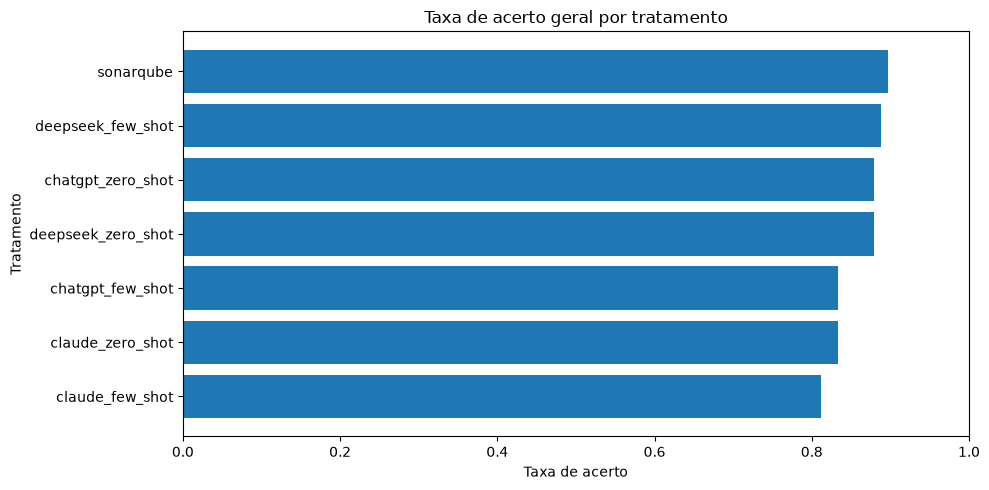

In [17]:
plt.figure(figsize=(10, 5))
plot_df = resumo_tratamento.sort_values("taxa_acerto", ascending=True)
plt.barh(plot_df["treatment"], plot_df["taxa_acerto"])
plt.xlabel("Taxa de acerto")
plt.ylabel("Tratamento")
plt.title("Taxa de acerto geral por tratamento")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

#### Gráfico de F1-Score

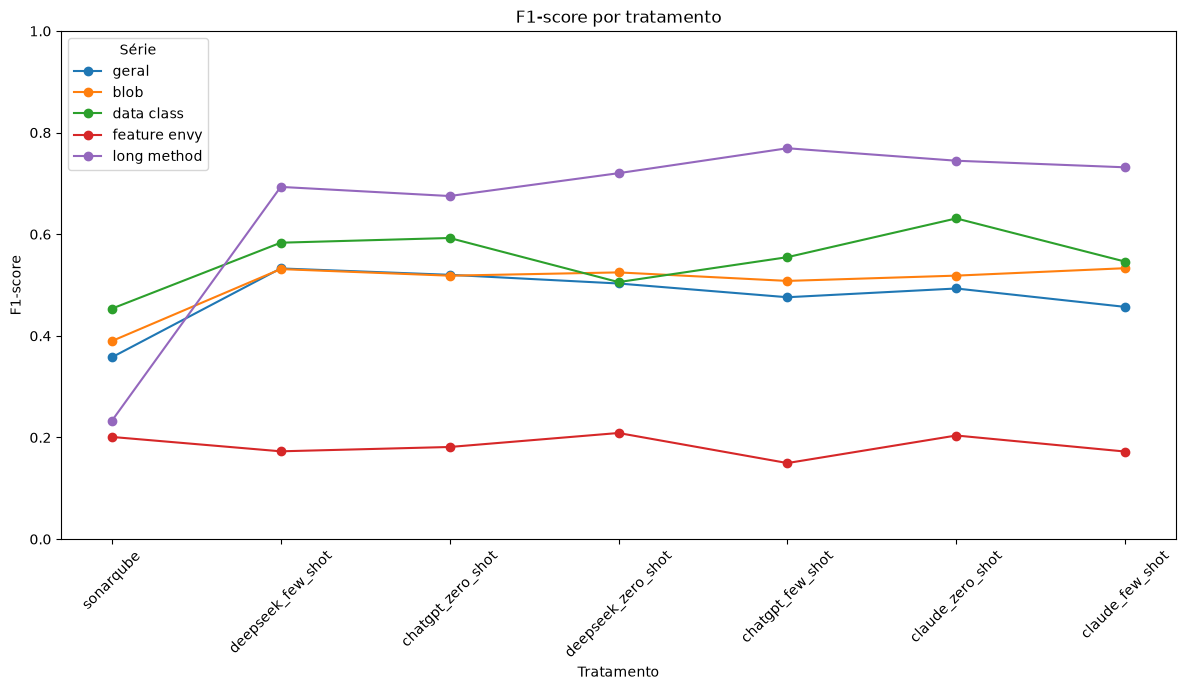

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Ordem dos tratamentos
ordem_tratamentos = [
    "sonarqube",
    "deepseek_few_shot",
    "chatgpt_zero_shot",
    "deepseek_zero_shot",
    "chatgpt_few_shot",
    "claude_zero_shot",
    "claude_few_shot"
]

# -------------------------
# Linha do F1 geral
# -------------------------
f1_geral = (
    resumo_tratamento[["treatment", "f1"]]
    .copy()
    .set_index("treatment")
    .reindex(ordem_tratamentos)
    .reset_index()
)

# -------------------------
# Linhas do F1 por smell
# -------------------------
f1_smell = (
    resumo_tratamento_smell[["treatment", "smell", "f1"]]
    .copy()
)

pivot_f1 = (
    f1_smell
    .pivot(index="treatment", columns="smell", values="f1")
    .reindex(ordem_tratamentos)
)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12, 7))

plt.plot(f1_geral["treatment"], f1_geral["f1"], marker="o", label="geral")

for smell in pivot_f1.columns:
    plt.plot(
        pivot_f1.index,
        pivot_f1[smell],
        marker="o",
        label=smell
    )

plt.title("F1-score por tratamento")
plt.xlabel("Tratamento")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title="Série")
plt.tight_layout()
plt.show()

#### F1 score geral somente:

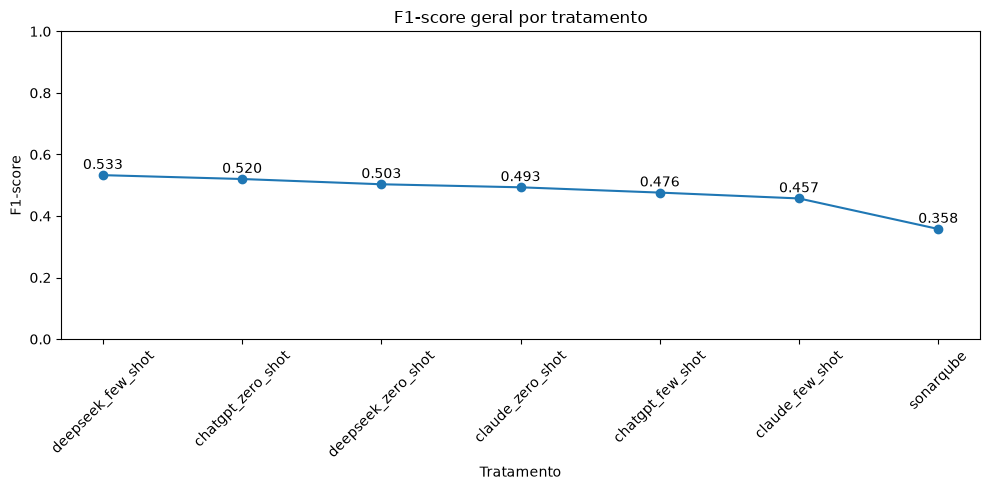

In [26]:
import matplotlib.pyplot as plt

f1_geral = (
    resumo_tratamento[["treatment", "f1"]]
    .sort_values("f1", ascending=False)
    .copy()
)

plt.figure(figsize=(10, 5))
plt.plot(f1_geral["treatment"], f1_geral["f1"], marker="o")
plt.title("F1-score geral por tratamento")
plt.xlabel("Tratamento")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=45)

for i, v in enumerate(f1_geral["f1"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 13. Resultados por smell

In [19]:
resumo_tratamento_smell = summarize_by(analise, ["treatment", "smell"])
display(resumo_tratamento_smell.sort_values(["smell", "taxa_acerto"], ascending=[True, False]))

resumo_tratamento_smell.to_csv(OUTPUT_DIR / "resumo_por_tratamento_e_smell.csv", index=False)

,treatment,smell,n,acertos,erros,taxa_acerto,tp,tn,fp,fn,precision,recall,specificity,f1
24,sonarqube,blob,2135.0,1897.0,238.0,0.888525,76.0,1821.0,27.0,211.0,0.737864,0.264808,0.985390,0.389744
16,deepseek_few_shot,blob,2135.0,1844.0,291.0,0.863700,165.0,1679.0,169.0,122.0,0.494012,0.574913,0.908550,0.531401
20,deepseek_zero_shot,blob,2135.0,1820.0,315.0,0.852459,174.0,1646.0,202.0,113.0,0.462766,0.606272,0.890693,0.524887
4,chatgpt_zero_shot,blob,2135.0,1782.0,353.0,0.834660,190.0,1592.0,256.0,97.0,0.426009,0.662021,0.861472,0.518417
8,claude_few_shot,blob,2135.0,1762.0,373.0,0.825293,213.0,1549.0,299.0,74.0,0.416016,0.742160,0.838203,0.533166
0,chatgpt_few_shot,blob,2135.0,1742.0,393.0,0.815925,203.0,1539.0,309.0,84.0,0.396484,0.707317,0.832792,0.508135
12,claude_zero_shot,blob,2135.0,1719.0,416.0,0.805152,224.0,1495.0,353.0,63.0,0.388215,0.780488,0.808983,0.518519
21,deepseek_zero_shot,data class,2139.0,1883.0,256.0,0.880318,131.0,1752.0,76.0,180.0,0.632850,0.421222,0.958425,0.505792
13,claude_zero_shot,data class,2139.0,1876.0,263.0,0.877045,225.0,1651.0,177.0,86.0,0.559701,0.723473,0.903173,0.631136
25,sonarqube,data class,2139.0,1845.0,294.0,0.862553,122.0,1723.0,105.0,189.0,0.537445,0.392283,0.942560,0.453532


smell,blob,data class,feature envy,long method
treatment,,,,
chatgpt_few_shot,0.815925,0.831230,0.732942,0.951439
chatgpt_zero_shot,0.834660,0.861150,0.877542,0.942896
claude_few_shot,0.825293,0.818139,0.657027,0.945594
claude_zero_shot,0.805152,0.877045,0.703436,0.946043
deepseek_few_shot,0.863700,0.859748,0.887483,0.937500
deepseek_zero_shot,0.852459,0.880318,0.845911,0.935701
sonarqube,0.888525,0.862553,0.931767,0.905126


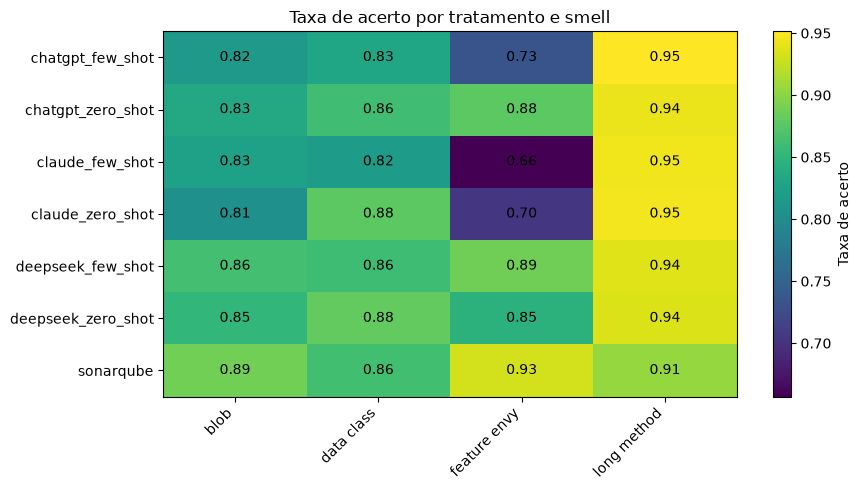

In [22]:
heat_acc = resumo_tratamento_smell.pivot(index="treatment", columns="smell", values="taxa_acerto")

display(heat_acc)

plt.figure(figsize=(9, 5))
plt.imshow(heat_acc.fillna(0), aspect="auto")
plt.xticks(range(len(heat_acc.columns)), heat_acc.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_acc.index)), heat_acc.index)
plt.colorbar(label="Taxa de acerto")
plt.title("Taxa de acerto por tratamento e smell")

for i in range(heat_acc.shape[0]):
    for j in range(heat_acc.shape[1]):
        val = heat_acc.iloc[i, j]
        if not pd.isna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 14. Resultados por tipo do trecho

Esta análise separa classes e métodos/funções.

In [31]:
resumo_tratamento_tipo = summarize_by(analise, ["treatment", "type"])
display(resumo_tratamento_tipo.sort_values(["type", "taxa_acerto"], ascending=[True, False]))

resumo_tratamento_tipo.to_csv(OUTPUT_DIR / "resumo_por_tratamento_e_tipo.csv", index=False)

,treatment,type,n,acertos,erros,taxa_acerto,tp,tn,fp,fn,precision,recall,specificity,f1,mcc,kappa,positivos_gt,positivos_pred
12,sonarqube,class,4274.0,3742.0,532.0,0.875526,198.0,3544.0,132.0,400.0,0.600000,0.331104,0.964091,0.426724,0.383638,0.363374,598.0,330.0
10,deepseek_zero_shot,class,4274.0,3703.0,571.0,0.866401,305.0,3398.0,278.0,293.0,0.523156,0.510033,0.924374,0.516511,0.439066,0.439018,598.0,583.0
8,deepseek_few_shot,class,4274.0,3683.0,591.0,0.861722,375.0,3308.0,368.0,223.0,0.504711,0.627090,0.899891,0.559284,0.482381,0.478415,598.0,743.0
2,chatgpt_zero_shot,class,4274.0,3624.0,650.0,0.847918,406.0,3218.0,458.0,192.0,0.469907,0.678930,0.875408,0.555404,0.478827,0.467312,598.0,864.0
6,claude_zero_shot,class,4274.0,3595.0,679.0,0.841132,449.0,3146.0,530.0,149.0,0.458631,0.750836,0.855822,0.569436,0.500798,0.478913,598.0,979.0
0,chatgpt_few_shot,class,4274.0,3520.0,754.0,0.823584,428.0,3092.0,584.0,170.0,0.422925,0.715719,0.841132,0.531677,0.454407,0.431720,598.0,1012.0
4,claude_few_shot,class,4274.0,3512.0,762.0,0.821713,447.0,3065.0,611.0,151.0,0.422495,0.747492,0.833787,0.539855,0.467220,0.439680,598.0,1058.0
13,sonarqube,function,4437.0,4075.0,362.0,0.918413,51.0,4024.0,67.0,295.0,0.432203,0.147399,0.983623,0.219828,0.218355,0.187606,346.0,118.0
9,deepseek_few_shot,function,4437.0,4049.0,388.0,0.912554,183.0,3866.0,225.0,163.0,0.448529,0.528902,0.945001,0.485411,0.439758,0.437981,346.0,408.0
3,chatgpt_zero_shot,function,4437.0,4039.0,398.0,0.910300,162.0,3877.0,214.0,184.0,0.430851,0.468208,0.947690,0.448753,0.400433,0.400023,346.0,376.0


## 15. Comparação zero-shot vs few-shot nas LLMs

Esta parte exclui o SonarQube, pois ele não usa prompt.

In [32]:
llm_analise = analise[analise["provider"].isin(["chatgpt", "claude", "deepseek"])].copy()

resumo_provider_prompt = summarize_by(llm_analise, ["provider", "prompt_version"])
display(resumo_provider_prompt.sort_values(["provider", "taxa_acerto"], ascending=[True, False]))

resumo_provider_prompt_smell = summarize_by(llm_analise, ["provider", "prompt_version", "smell"])
display(resumo_provider_prompt_smell.sort_values(["smell", "provider", "taxa_acerto"], ascending=[True, True, False]))

resumo_provider_prompt.to_csv(OUTPUT_DIR / "resumo_llms_por_provider_e_prompt.csv", index=False)
resumo_provider_prompt_smell.to_csv(OUTPUT_DIR / "resumo_llms_por_provider_prompt_e_smell.csv", index=False)

,provider,prompt_version,n,acertos,erros,taxa_acerto,tp,tn,fp,fn,precision,recall,specificity,f1,mcc,kappa,positivos_gt,positivos_pred
1,chatgpt,zero_shot,8711.0,7663.0,1048.0,0.879692,568.0,7095.0,672.0,376.0,0.458065,0.601695,0.913480,0.520147,0.458318,0.452812,944.0,1240.0
0,chatgpt,few_shot,8711.0,7258.0,1453.0,0.833199,660.0,6598.0,1169.0,284.0,0.360853,0.699153,0.849491,0.476019,0.418735,0.388619,944.0,1829.0
3,claude,zero_shot,8710.0,7255.0,1455.0,0.832951,708.0,6547.0,1219.0,236.0,0.367410,0.750000,0.843034,0.493208,0.444132,0.406921,944.0,1927.0
2,claude,few_shot,8711.0,7069.0,1642.0,0.811503,691.0,6378.0,1389.0,253.0,0.332212,0.731992,0.821166,0.457011,0.403312,0.361881,944.0,2080.0
4,deepseek,few_shot,8711.0,7732.0,979.0,0.887613,558.0,7174.0,593.0,386.0,0.484796,0.591102,0.923651,0.532697,0.472512,0.469531,944.0,1151.0
5,deepseek,zero_shot,8711.0,7656.0,1055.0,0.878889,534.0,7122.0,645.0,410.0,0.452926,0.565678,0.916956,0.503062,0.438550,0.435064,944.0,1179.0


,provider,prompt_version,smell,n,acertos,erros,taxa_acerto,tp,tn,fp,fn,precision,recall,specificity,f1,mcc,kappa,positivos_gt,positivos_pred
4,chatgpt,zero_shot,blob,2135.0,1782.0,353.0,0.834660,190.0,1592.0,256.0,97.0,0.426009,0.662021,0.861472,0.518417,0.439259,0.424230,287.0,446.0
0,chatgpt,few_shot,blob,2135.0,1742.0,393.0,0.815925,203.0,1539.0,309.0,84.0,0.396484,0.707317,0.832792,0.508135,0.431499,0.405759,287.0,512.0
8,claude,few_shot,blob,2135.0,1762.0,373.0,0.825293,213.0,1549.0,299.0,74.0,0.416016,0.742160,0.838203,0.533166,0.463658,0.436000,287.0,512.0
12,claude,zero_shot,blob,2135.0,1719.0,416.0,0.805152,224.0,1495.0,353.0,63.0,0.388215,0.780488,0.808983,0.518519,0.452775,0.413152,287.0,577.0
16,deepseek,few_shot,blob,2135.0,1844.0,291.0,0.863700,165.0,1679.0,169.0,122.0,0.494012,0.574913,0.908550,0.531401,0.453968,0.452187,287.0,334.0
20,deepseek,zero_shot,blob,2135.0,1820.0,315.0,0.852459,174.0,1646.0,202.0,113.0,0.462766,0.606272,0.890693,0.524887,0.445031,0.439413,287.0,376.0
5,chatgpt,zero_shot,data class,2139.0,1842.0,297.0,0.861150,216.0,1626.0,202.0,95.0,0.516746,0.694534,0.889497,0.592593,0.519189,0.511071,311.0,418.0
1,chatgpt,few_shot,data class,2139.0,1778.0,361.0,0.831230,225.0,1553.0,275.0,86.0,0.450000,0.723473,0.849562,0.554871,0.477282,0.457636,311.0,500.0
13,claude,zero_shot,data class,2139.0,1876.0,263.0,0.877045,225.0,1651.0,177.0,86.0,0.559701,0.723473,0.903173,0.631136,0.565428,0.558801,311.0,402.0
9,claude,few_shot,data class,2139.0,1750.0,389.0,0.818139,234.0,1516.0,312.0,77.0,0.428571,0.752412,0.829322,0.546091,0.470314,0.442876,311.0,546.0


## 16. Matrizes de confusão

Formato da matriz:

- `TN`: referência NÃO e predição NÃO.
- `FP`: referência NÃO e predição SIM.
- `FN`: referência SIM e predição NÃO.
- `TP`: referência SIM e predição SIM.

In [33]:
confusao = summarize_by(analise, "treatment")[[
    "treatment", "tn", "fp", "fn", "tp", "n", "taxa_acerto", "precision", "recall", "f1"
]].sort_values("treatment")

display(confusao)
confusao.to_csv(OUTPUT_DIR / "matriz_confusao_por_tratamento.csv", index=False)

,treatment,tn,fp,fn,tp,n,taxa_acerto,precision,recall,f1
0,chatgpt_few_shot,6598.0,1169.0,284.0,660.0,8711.0,0.833199,0.360853,0.699153,0.476019
1,chatgpt_zero_shot,7095.0,672.0,376.0,568.0,8711.0,0.879692,0.458065,0.601695,0.520147
2,claude_few_shot,6378.0,1389.0,253.0,691.0,8711.0,0.811503,0.332212,0.731992,0.457011
3,claude_zero_shot,6547.0,1219.0,236.0,708.0,8710.0,0.832951,0.367410,0.750000,0.493208
4,deepseek_few_shot,7174.0,593.0,386.0,558.0,8711.0,0.887613,0.484796,0.591102,0.532697
5,deepseek_zero_shot,7122.0,645.0,410.0,534.0,8711.0,0.878889,0.452926,0.565678,0.503062
6,sonarqube,7568.0,199.0,695.0,249.0,8711.0,0.897371,0.555804,0.263771,0.357759


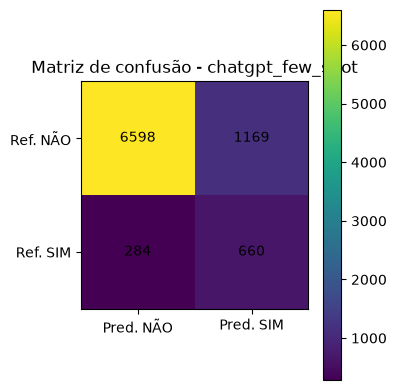

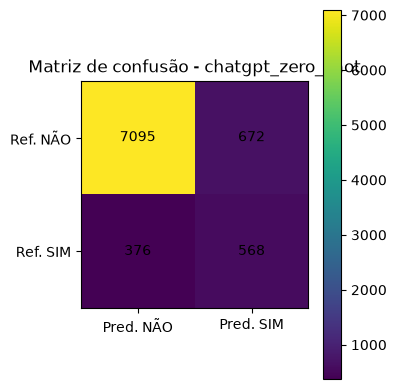

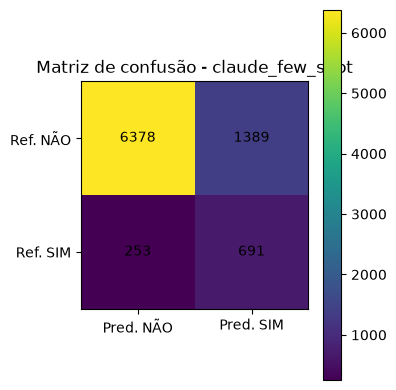

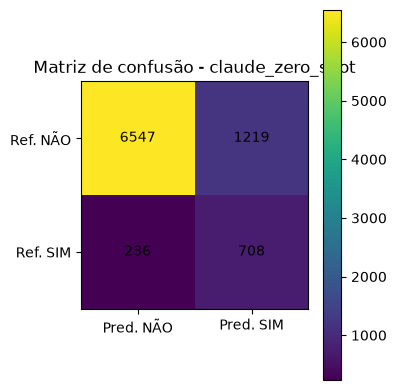

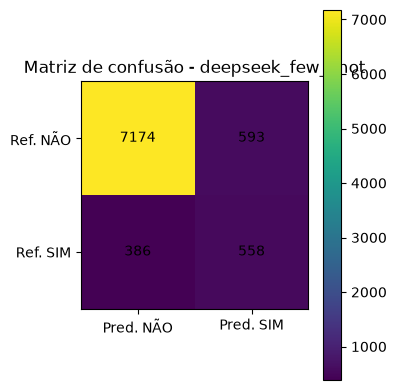

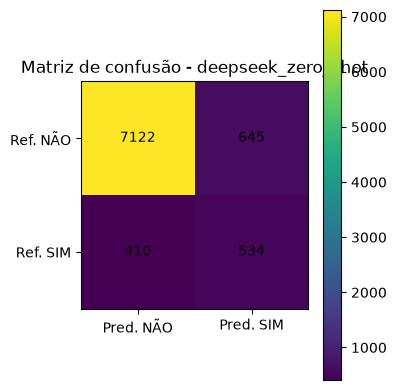

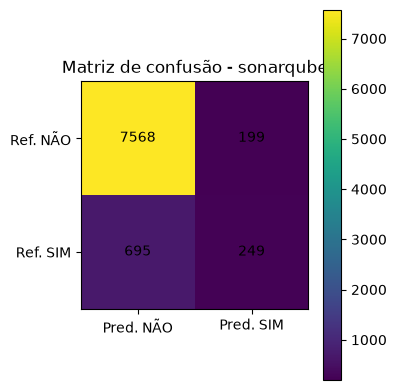

In [34]:
def plot_confusion_for_treatment(df, treatment):
    d = df[(df["treatment"] == treatment)].dropna(subset=["y_true", "y_pred"])
    y_true = d["y_true"].astype(int)
    y_pred = d["y_pred"].astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.xticks([0, 1], ["Pred. NÃO", "Pred. SIM"])
    plt.yticks([0, 1], ["Ref. NÃO", "Ref. SIM"])
    plt.title(f"Matriz de confusão - {treatment}")
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

for treatment in sorted(analise["treatment"].dropna().unique()):
    plot_confusion_for_treatment(analise, treatment)

## 17. Análise Descritiva

### 17.1 Prepara base para análise descritiva 

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Garante base válida
analise_valida = analise.dropna(subset=["y_true", "y_pred"]).copy()

analise_valida["y_true"] = analise_valida["y_true"].astype(int)
analise_valida["y_pred"] = analise_valida["y_pred"].astype(int)
analise_valida["acerto"] = (
    analise_valida["y_true"] == analise_valida["y_pred"]
).astype(int)

# Tabela pareada: linhas = sample_id + smell; colunas = tratamentos
acertos_wide = (
    analise_valida
    .pivot_table(
        index=["sample_id", "smell"],
        columns="treatment",
        values="acerto",
        aggfunc="first"
    )
)

display(acertos_wide.head())

treatment               chatgpt_few_shot  chatgpt_zero_shot  claude_few_shot  \
sample_id smell                                                                
3698323   blob                       1.0                1.0              1.0   
          data class                 1.0                1.0              1.0   
3698602   feature envy               1.0                1.0              1.0   
          long method                1.0                1.0              1.0   
3698665   feature envy               1.0                1.0              1.0   

treatment               claude_zero_shot  deepseek_few_shot  \
sample_id smell                                               
3698323   blob                       1.0                1.0   
          data class                 1.0                1.0   
3698602   feature envy               1.0                1.0   
          long method                1.0                1.0   
3698665   feature envy               1.0                1.0   

treatment               deepseek_zero_shot  sonarqube  
sample_id smell                                        
3698323   blob                         1.0        1.0  
          data class                   1.0        1.0  
3698602   feature envy                 1.0        1.0  
          long method                  1.0        1.0  
3698665   feature envy                 1.0        1.0

## 17.2 Percentis da taxa de acerto por tratamento

In [34]:
percentis_taxa_tratamento = (
    resumo_tratamento_smell
    .groupby("treatment")["taxa_acerto"]
    .quantile([0, 0.25, 0.50, 0.75, 1])
    .unstack()
    .reset_index()
)

percentis_taxa_tratamento.columns = [
    "treatment",
    "min",
    "p25",
    "mediana",
    "p75",
    "max"
]

percentis_taxa_tratamento = percentis_taxa_tratamento.sort_values(
    "mediana",
    ascending=False
)

display(percentis_taxa_tratamento)

,treatment,min,p25,mediana,p75,max
6,sonarqube,0.862553,0.882032,0.896825,0.911786,0.931767
4,deepseek_few_shot,0.859748,0.862712,0.875592,0.899987,0.937500
1,chatgpt_zero_shot,0.834660,0.854528,0.869346,0.893880,0.942896
5,deepseek_zero_shot,0.845911,0.850822,0.866388,0.894164,0.935701
3,claude_zero_shot,0.703436,0.779723,0.841099,0.894295,0.946043
0,chatgpt_few_shot,0.732942,0.795179,0.823577,0.861282,0.951439
2,claude_few_shot,0.657027,0.777861,0.821716,0.855368,0.945594


## 17.3 Box-plot da taxa de acerto por smell

### 17.3.1 Box-plot por tratamento

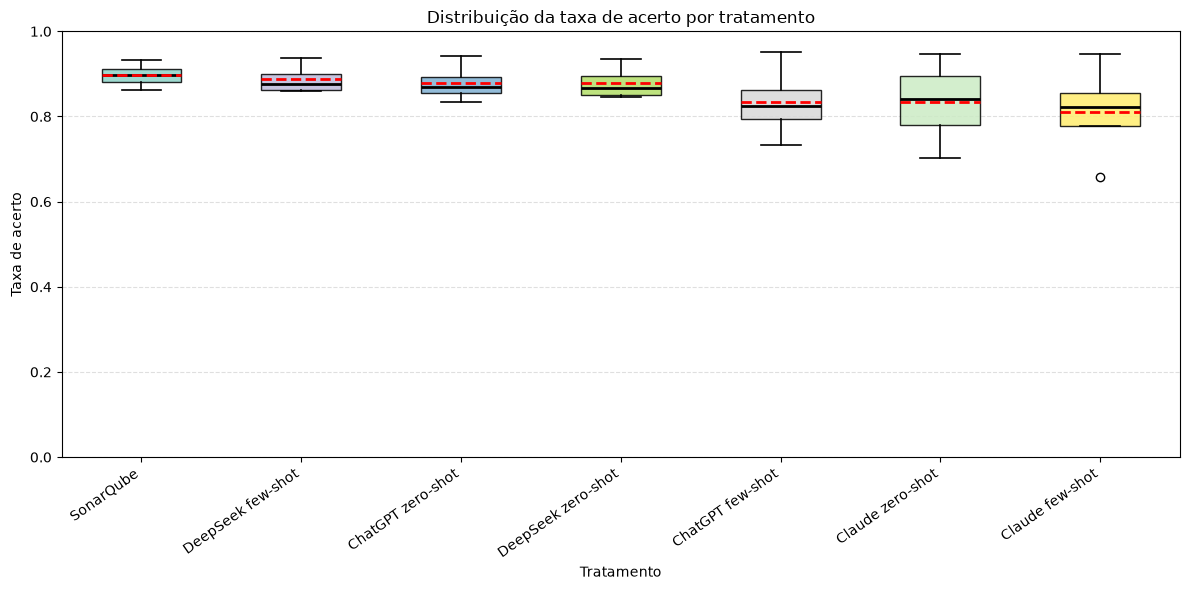

In [21]:
import matplotlib.pyplot as plt
import numpy as np

ordem_tratamentos = [
    "sonarqube",
    "deepseek_few_shot",
    "chatgpt_zero_shot",
    "deepseek_zero_shot",
    "chatgpt_few_shot",
    "claude_zero_shot",
    "claude_few_shot"
]

nomes_tratamentos = {
    "sonarqube": "SonarQube",
    "deepseek_few_shot": "DeepSeek few-shot",
    "chatgpt_zero_shot": "ChatGPT zero-shot",
    "deepseek_zero_shot": "DeepSeek zero-shot",
    "chatgpt_few_shot": "ChatGPT few-shot",
    "claude_zero_shot": "Claude zero-shot",
    "claude_few_shot": "Claude few-shot"
}

dados_boxplot = [
    resumo_tratamento_smell[
        resumo_tratamento_smell["treatment"] == tratamento
    ]["taxa_acerto"].values
    for tratamento in ordem_tratamentos
]

labels = [nomes_tratamentos[t] for t in ordem_tratamentos]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    dados_boxplot,
    patch_artist=True,
    showmeans=True,
    meanline=True
)

cores = plt.cm.Set3(np.linspace(0, 1, len(ordem_tratamentos)))

for patch, cor in zip(box["boxes"], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

for mean in box["means"]:
    mean.set_color("red")
    mean.set_linewidth(2)

for whisker in box["whiskers"]:
    whisker.set_linewidth(1.2)

for cap in box["caps"]:
    cap.set_linewidth(1.2)

plt.title("Distribuição da taxa de acerto por tratamento")
plt.xlabel("Tratamento")
plt.ylabel("Taxa de acerto")
plt.ylim(0, 1)

plt.xticks(
    ticks=range(1, len(labels) + 1),
    labels=labels,
    rotation=35,
    ha="right"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 17.4 Dispersão entre taxa de acerto e F1-score

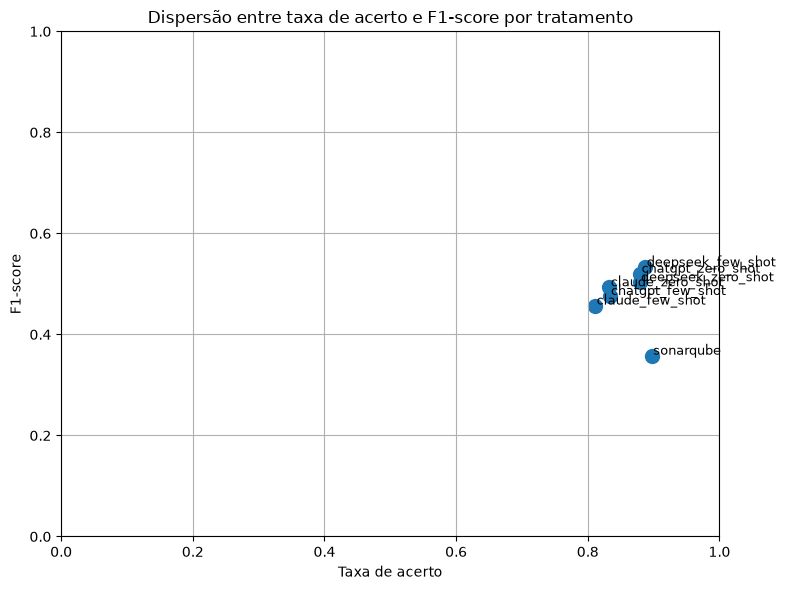

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    resumo_tratamento["taxa_acerto"],
    resumo_tratamento["f1"],
    s=100
)

for _, row in resumo_tratamento.iterrows():
    plt.text(
        row["taxa_acerto"] + 0.002,
        row["f1"] + 0.002,
        row["treatment"],
        fontsize=9
    )

plt.title("Dispersão entre taxa de acerto e F1-score por tratamento")
plt.xlabel("Taxa de acerto")
plt.ylabel("F1-score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()

## 17.5 Tabela descritiva geral

In [31]:
descritiva_f1_tratamento = (
    resumo_tratamento_smell
    .groupby("treatment")["f1"]
    .agg(
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        maximo="max"
    )
    .reset_index()
    .sort_values("mediana", ascending=False)
)

display(descritiva_f1_tratamento)

descritiva_f1_tratamento.to_csv(
    OUTPUT_DIR / "descritiva_f1_por_tratamento.csv",
    index=False
)

,treatment,media,mediana,desvio_padrao,minimo,p25,p75,maximo
3,claude_zero_shot,0.524555,0.574827,0.232867,0.203883,0.439860,0.659522,0.744681
4,deepseek_few_shot,0.495162,0.557367,0.225266,0.172757,0.441740,0.610789,0.693157
1,chatgpt_zero_shot,0.491868,0.555505,0.216741,0.181269,0.434130,0.613242,0.675192
2,claude_few_shot,0.495816,0.539629,0.233972,0.172301,0.442950,0.592495,0.731707
0,chatgpt_few_shot,0.495469,0.531503,0.257055,0.149640,0.418511,0.608461,0.769231
5,deepseek_zero_shot,0.489913,0.515339,0.210952,0.208817,0.431548,0.573704,0.720157
6,sonarqube,0.319265,0.311235,0.121732,0.201058,0.224810,0.405691,0.453532


# ---------------------------------------------------------------------------------